In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
X_train = np.load('/content/drive/MyDrive/X_train_aug.npy')
X_test = np.load('/content/drive/MyDrive/X_test_aug.npy')

y_train = np.load('/content/drive/MyDrive/y_train_aug.npy')
y_test = np.load('/content/drive/MyDrive/y_test_aug.npy')

In [4]:
print(X_train.shape)
print(y_train.shape)

(40000, 256, 35)
(40000,)


In [5]:
print("Train OCD:", sum(y_train == 1))
print("Train Non-OCD:", sum(y_train == 0))

Train OCD: 16000
Train Non-OCD: 24000


In [6]:
X_ocd = X_train[y_train == 1]
y_ocd = y_train[y_train == 1]

print("OCD samples:", X_ocd.shape)

OCD samples: (16000, 256, 35)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(256, 37)))
model.add(Dropout(0.3))

model.add(LSTM(32))
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 256, 64)        │        26,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,073 (152.63 KB)

 Trainable params: 39,073 (152.63 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

y_train = y_train.astype('int32')
y_test = y_test.astype('int32')

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [13]:
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    callbacks=[early_stopping],
    validation_split=0.1,
    shuffle=True
)

Epoch 1/25
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.5991 - loss: 0.6734 - val_accuracy: 0.5980 - val_loss: 0.6700
Epoch 2/25
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.6098 - loss: 0.6582 - val_accuracy: 0.6162 - val_loss: 0.6502
Epoch 3/25
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.6828 - loss: 0.5920 - val_accuracy: 0.6930 - val_loss: 0.5748
Epoch 4/25
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.7676 - loss: 0.4865 - val_accuracy: 0.7580 - val_loss: 0.5018
Epoch 5/25
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.8283 - loss: 0.3894 - val_accuracy: 0.7895 - val_loss: 0.4576
Epoch 6/25
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.8681 - loss: 0.3167 - val_accuracy: 0.8175 - val_loss: 0.4273
Epoch 7/25
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - accuracy: 0.8983 - loss: 0.2585 - val_accuracy: 0.8355 - val_loss: 0.4207
Epoch 8/25
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.9157 -

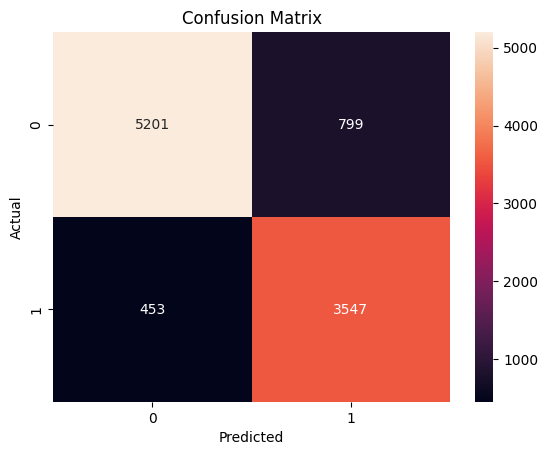

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

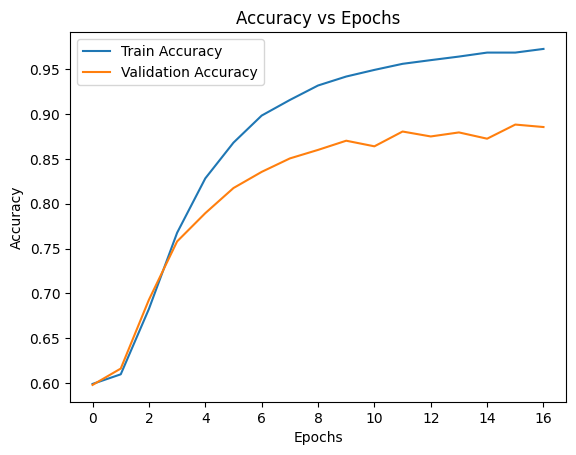

In [21]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.show()

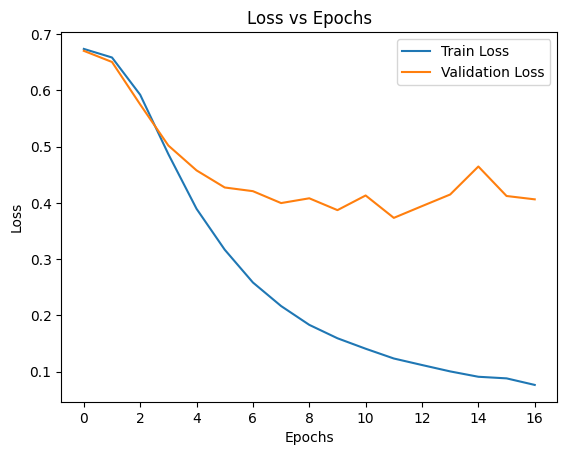

In [23]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()

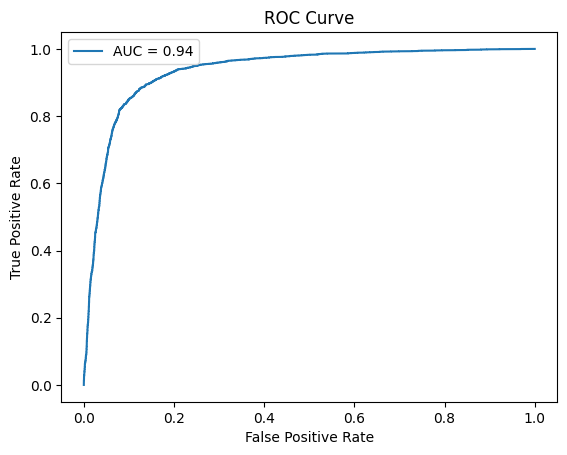

In [24]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

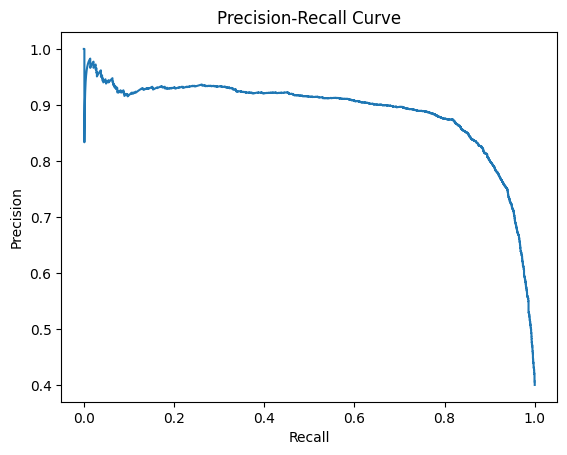

In [25]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [27]:
y_pred2 = (y_pred_prob > 0.6).astype(int)
print("Test Accuracy:", accuracy_score(y_test, y_pred2))

Test Accuracy: 0.8781


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred2, target_names=["Non-OCD", "OCD"]))

              precision    recall  f1-score   support

     Non-OCD       0.91      0.88      0.90      6000
         OCD       0.83      0.87      0.85      4000

    accuracy                           0.88     10000
   macro avg       0.87      0.88      0.87     10000
weighted avg       0.88      0.88      0.88     10000



In [29]:
print("Training Accuracy:", history.history['accuracy'][-1])

Training Accuracy: 0.9725833535194397
